# Assignment 2 (Option B) Support Vector Machine Implementation
## Breast Cancer Classification using Support Vector Machines
**Course:** CSI4145 Machine Learning  
**Student:** Aicha Lfakir  
**Core paper:** Cortes & Vapnik (1996), *Support-Vector Networks*

# 1. Introduction

This notebook implements a simplified version of the core idea introduced in Cortes and Vapnik (1996): the Support Vector Machine (SVM). The objective is to apply SVMs to a real-world classification problem using a complete machine learning pipeline.

The selected task is breast cancer diagnosis using the Breast Cancer Wisconsin dataset. This is a binary classification problem where the goal is to distinguish between malignant and benign tumors based on numerical features extracted from medical images.

This problem is particularly well-suited for SVMs because:
- it is a binary classification task
- the dataset contains continuous numerical features
- margin-based classifiers like SVM are known to perform well in such settings

This notebook follows a structured workflow including data exploration, preprocessing, model training, evaluation, and interpretation of results in relation to the original paper.

# 2. Dataset Selection and Justification

The dataset used in this notebook is the Breast Cancer Wisconsin dataset, available through scikit-learn. It contains diagnostic measurements computed from digitized images of breast mass cell nuclei.

This dataset is appropriate for this assignment for several reasons:
- it represents a real-world medical classification problem
- it is a binary classification task, which aligns well with the SVM framework
- it contains multiple numerical features, making it suitable for distance-based models
- it is well-structured and widely used for benchmarking classification algorithms

The target variable indicates whether a tumor is malignant or benign.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Optional: make plots a bit cleaner in notebooks
plt.rcParams["figure.figsize"] = (8, 5)

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("\nTarget names:", data.target_names)

Feature matrix shape: (569, 30)
Target vector shape: (569,)

Target names: ['malignant' 'benign']


In [3]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
print("Missing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum())

print("\nClass distribution:")
print(y.value_counts())

print("\nClass proportions:")
print(y.value_counts(normalize=True))

Missing values in X: 0
Missing values in y: 0

Class distribution:
target
1    357
0    212
Name: count, dtype: int64

Class proportions:
target
1    0.627417
0    0.372583
Name: proportion, dtype: float64


# 3. Data Exploration

Before training any model, it is important to understand the structure and properties of the dataset.

The dataset contains only numerical features, and no missing values are present. This simplifies preprocessing but also highlights the importance of feature scaling, as SVMs are sensitive to the magnitude of input features.

The class distribution shows that the dataset is slightly imbalanced, with more benign cases than malignant ones. However, the imbalance is not severe and does not require special handling.

Overall, the dataset appears clean, structured, and appropriate for applying Support Vector Machines.

In [5]:
X.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


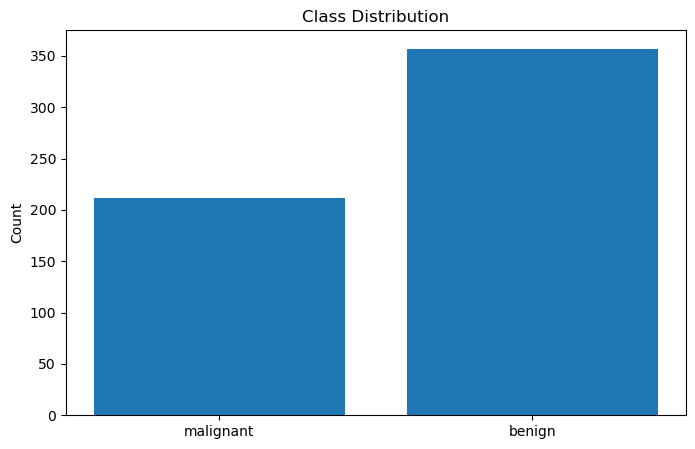

In [6]:
class_counts = y.value_counts().sort_index()

plt.bar(["malignant", "benign"], class_counts.values)
plt.title("Class Distribution")
plt.ylabel("Count")
plt.show()

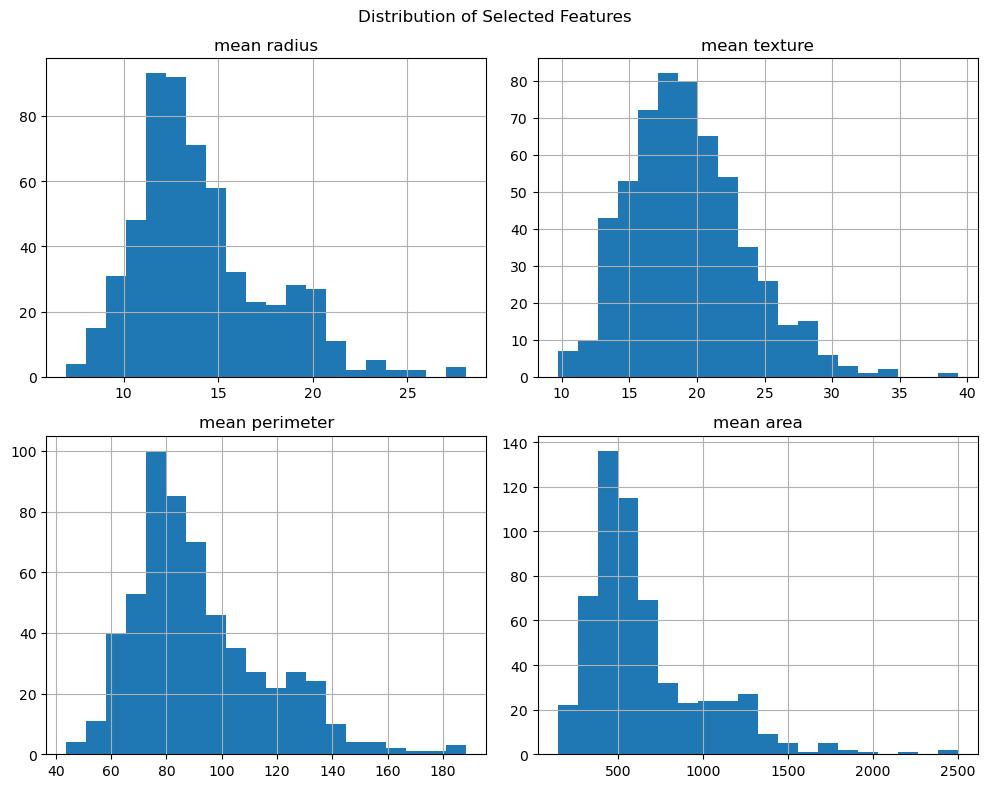

In [7]:
selected_features = ["mean radius", "mean texture", "mean perimeter", "mean area"]
X[selected_features].hist(bins=20, figsize=(10, 8))
plt.suptitle("Distribution of Selected Features")
plt.tight_layout()
plt.show()

# 4. Data Preprocessing

Support Vector Machines rely on distance-based computations, which makes them highly sensitive to the scale of input features. For this reason, feature standardization is an essential preprocessing step.

In this notebook, the dataset is split into training and test sets, and feature scaling is applied using a pipeline. This ensures that the scaling is learned only from the training data and then applied consistently to the test data, avoiding data leakage.

This approach reflects good machine learning practice and ensures that the evaluation remains reliable.


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (455, 30)
Test set shape: (114, 30)


In [9]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    results = {
        "Model": model_name,
        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "Test Precision": precision_score(y_test, y_test_pred),
        "Test Recall": recall_score(y_test, y_test_pred),
        "Test F1": f1_score(y_test, y_test_pred)
    }

    print(f"=== {model_name} ===")
    print(pd.DataFrame([results]))
    print("\nClassification Report:")
    print(classification_report(y_test, y_test_pred, target_names=data.target_names))

    cm = confusion_matrix(y_test, y_test_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
    disp.plot()
    plt.title(f"Confusion Matrix — {model_name}")
    plt.show()

    return results

# 5. Baseline Model 1: Linear SVM

The first model used is a linear Support Vector Machine. This corresponds directly to the original formulation introduced by Cortes and Vapnik, where the goal is to find a hyperplane that maximizes the margin between two classes.

The linear SVM serves as a strong baseline model. It is simple, interpretable, and often performs well when the data are approximately linearly separable.

In this case, the model achieves high accuracy and balanced precision and recall, indicating that the data may already be well-structured in the original feature space.

=== Linear SVM ===
        Model  Train Accuracy  Test Accuracy  Test Precision  Test Recall  \
0  Linear SVM        0.991209       0.973684        0.985915     0.972222   

    Test F1  
0  0.979021  

Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.98      0.96        42
      benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



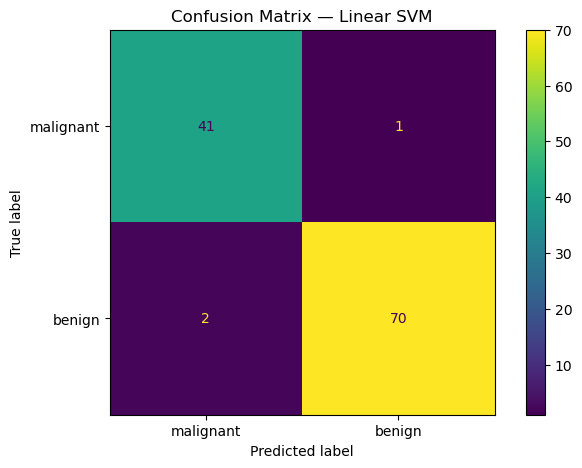

In [10]:
linear_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="linear", C=1.0))
])

linear_svm.fit(X_train, y_train)

linear_results = evaluate_model(
    linear_svm,
    X_train, X_test,
    y_train, y_test,
    model_name="Linear SVM"
)

# 6. Baseline Model 2 : RBF SVM

The second model uses a radial basis function (RBF) kernel. This allows the SVM to model non-linear relationships by implicitly mapping the data into a higher-dimensional space.

The RBF SVM slightly outperforms the linear model, suggesting that there may be some non-linear structure in the data. However, the improvement is relatively small.

This indicates that while non-linear modeling provides additional flexibility, the dataset is already close to linearly separable.

=== RBF SVM ===
     Model  Train Accuracy  Test Accuracy  Test Precision  Test Recall  \
0  RBF SVM        0.982418       0.982456        0.986111     0.986111   

    Test F1  
0  0.986111  

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



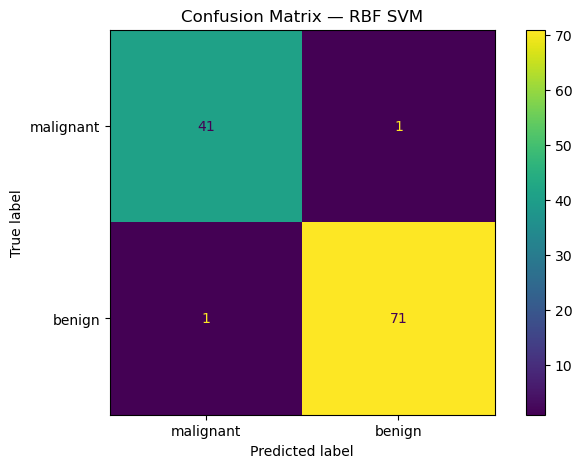

In [17]:
rbf_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", C=1.0, gamma="scale"))
])

rbf_svm.fit(X_train, y_train)

rbf_results = evaluate_model(
    rbf_svm,
    X_train, X_test,
    y_train, y_test,
    model_name="RBF SVM"
)

In [18]:
baseline_comparison = pd.DataFrame([linear_results, rbf_results])
baseline_comparison

,Model,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1
0,Linear SVM,0.991209,0.973684,0.985915,0.972222,0.979021
1,RBF SVM,0.982418,0.982456,0.986111,0.986111,0.986111


# 7. Hyperparameter Tuning

To further improve performance, hyperparameter tuning is performed using GridSearchCV.

The two main parameters explored are:
- C: controls the trade-off between maximizing the margin and minimizing classification errors
- gamma: controls the influence of individual training samples in the RBF kernel

The tuning process identifies the best combination of parameters using cross-validation. In this case, the tuned model does not significantly outperform the baseline RBF model, which suggests that the default parameters were already well-suited for this dataset.

This result highlights that for relatively clean and well-structured datasets, extensive tuning may provide only marginal improvements.

In [19]:
rbf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf"))
])

param_grid = {
    "svc__C": [0.1, 1, 10, 100],
    "svc__gamma": ["scale", 0.01, 0.1, 1]
}

grid_search = GridSearchCV(
    estimator=rbf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

Best parameters: {'svc__C': 10, 'svc__gamma': 0.01}
Best CV score: 0.9844323436002114


best_rbf_svm = grid_search.best_estimator_

tuned_results = evaluate_model(
    best_rbf_svm,
    X_train, X_test,
    y_train, y_test,
    model_name="Tuned RBF SVM"
)

In [21]:
final_comparison = pd.DataFrame([linear_results, rbf_results, tuned_results])
final_comparison

,Model,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1
0,Linear SVM,0.991209,0.973684,0.985915,0.972222,0.979021
1,RBF SVM,0.982418,0.982456,0.986111,0.986111,0.986111
2,Tuned RBF SVM,0.986813,0.982456,0.986111,0.986111,0.986111


# 8. Results and Interpretation

The results show that all SVM models achieve strong performance on this classification task.

The linear SVM already provides high accuracy and balanced precision and recall, which indicates that the dataset is close to linearly separable. This supports the idea that maximizing the margin alone can lead to good generalization.

The RBF SVM slightly improves performance by allowing more flexible decision boundaries. However, the improvement is relatively small, suggesting that the added complexity is not strictly necessary for this dataset.

Interestingly, hyperparameter tuning does not significantly improve the results. This suggests that the dataset is not highly sensitive to parameter changes and that the baseline configuration is already effective.

Overall, these results demonstrate that SVM is a robust and reliable method for structured numerical classification tasks.

# 9. Discussion in Relation to Cortes & Vapnik (1996)

This experiment reflects several core ideas from the original SVM paper.

First, the linear SVM corresponds directly to the idea of finding a maximum-margin separating hyperplane. Rather than simply fitting the training data, the model seeks a boundary with better generalization properties.

Second, the RBF kernel illustrates the kernel-based extension emphasized in the paper. Even when the data are not perfectly separable in the original feature space, kernel methods allow SVM to operate implicitly in a higher-dimensional space.

Third, the importance of the parameter **C** in this notebook reflects the soft-margin formulation introduced by Cortes and Vapnik. A larger value of **C** penalizes classification errors more strongly, while a smaller value allows a wider margin at the cost of more training violations.

Finally, this notebook differs from the original paper in important ways. The original work studied both theory and large-scale empirical results with polynomial kernels. In contrast, this notebook uses a simplified modern implementation with scikit-learn and focuses on reproducibility, clarity, and evaluation on a standard dataset.

# 10. Limitations

This notebook has several limitations.

First, it uses a relatively small and clean dataset. As a result, the models achieve very high performance, and the differences between linear and non-linear approaches are limited.

Second, the implementation relies on scikit-learn rather than deriving the SVM optimization problem from first principles. This simplifies the workflow but abstracts away some of the mathematical details.

Third, the notebook does not include visualization of decision boundaries due to the high dimensionality of the dataset.

Finally, only a limited set of hyperparameters is explored. In more complex real-world datasets, a more extensive search could lead to greater performance improvements.

Despite these limitations, the notebook provides a clear and complete demonstration of SVM in practice.

# 11. Conclusion

This notebook implemented a practical application of Support Vector Machines based on the foundational work of Cortes and Vapnik (1996).

Using the Breast Cancer Wisconsin dataset, it demonstrated a complete machine learning pipeline, including data exploration, preprocessing, model training, evaluation, and interpretation.

The results confirm that SVM is a powerful and reliable method for classification tasks, especially when the data are well-structured. In particular, the strong performance of the linear model highlights the importance of margin maximization as a core learning principle.

More broadly, this project shows how theoretical ideas from foundational machine learning research can be effectively applied to real-world problems using modern tools.

# References

Cortes, C., & Vapnik, V. (1996). Support-vector networks. Machine Learning, 20(3), 273–297.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., ... & Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. Journal of Machine Learning Research, 12, 2825–2830.

Scikit-learn documentation: https://scikit-learn.org/stable/